In [19]:
import os
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
ROOT_DIR = "/content/air-quality"
DATA_DIR = os.path.join(ROOT_DIR, "data")

SAVED_MODEL_DIR = os.path.join(ROOT_DIR, "saved_models")
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

dataset_path = os.path.join(DATA_DIR, "air_quality_data.csv")

# create folders if not exist
os.makedirs(DATA_DIR, exist_ok=True)


In [4]:
df = pd.read_csv(dataset_path)
df.head()

,PM2.5,PM10,NO2,CO,Temperature,Humidity,AQI,Safe
0,74.908024,55.539879,26.170568,6.727030,18.599794,39.363552,194.477086,0
1,190.142861,162.570284,24.697880,7.966814,30.271616,47.343566,51.715909,1
2,146.398788,261.883751,90.625458,2.504679,28.008046,85.454739,261.718369,0
3,119.731697,219.667466,24.954620,6.248741,-2.305005,34.000439,183.934872,0
4,31.203728,241.968344,27.194973,5.717460,-2.537527,86.964968,47.161165,1


In [5]:
X = df[['PM2.5', 'PM10', 'NO2', 'CO', 'Temperature', 'Humidity']]
y_reg = df['AQI']
y_clf = df['Safe']
X = X.fillna(X.mean())

In [6]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

scaler_initial = StandardScaler()
X_scaled = scaler_initial.fit_transform(X)



In [18]:
# Add this before regression evaluation
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

In [7]:


X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_reg_train)

LinearRegression()

In [9]:
import joblib
joblib.dump(linear_model, os.path.join(SAVED_MODEL_DIR, 'linear_model.pkl'))

['/content/air-quality/saved_models/linear_model.pkl']

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
poly_reg = make_pipeline(poly, LinearRegression())
poly_reg.fit(X_train, y_reg_train)
joblib.dump(linear_model, os.path.join(SAVED_MODEL_DIR, 'poly_model.pkl'))

['/content/air-quality/saved_models/poly_model.pkl']

In [11]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42
)

logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_clf_train)
joblib.dump(logistic_model, os.path.join(SAVED_MODEL_DIR, 'logistic_model.pkl'))

['/content/air-quality/saved_models/logistic_model.pkl']

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_clf_train)
joblib.dump(rf_classifier, os.path.join(SAVED_MODEL_DIR, 'rf_classifier.pkl'))  # ← FIXED


['/content/air-quality/saved_models/rf_classifier.pkl']

In [13]:
reg_models = {
    'Linear': linear_model,
    'Polynomial': poly_reg,
}

clf_models = {
    'Logistic': logistic_model,
    'RandomForest': rf_classifier
}

In [14]:
from sklearn.metrics import mean_squared_error

for name, model in reg_models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_reg_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}")

Linear - MSE: 7329.39
Polynomial - MSE: 7573.59


In [15]:
from sklearn.metrics import accuracy_score

for name, model in clf_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_clf_test, y_pred)
    print(f"{name} - Accuracy: {acc:.2f}")

Logistic - Accuracy: 0.69
RandomForest - Accuracy: 0.62


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, r2_score

# For regression — add R² score (more meaningful than raw MSE)
r2 = r2_score(y_reg_test, y_pred)

# For classification — full report
print(classification_report(y_clf_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       137
           1       0.32      0.19      0.24        63

    accuracy                           0.62       200
   macro avg       0.51      0.50      0.49       200
weighted avg       0.57      0.62      0.59       200



In [20]:

from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_clf_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [21]:
from sklearn.model_selection import GridSearchCV
params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_clf_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200]})

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/correlation_heatmap.png'

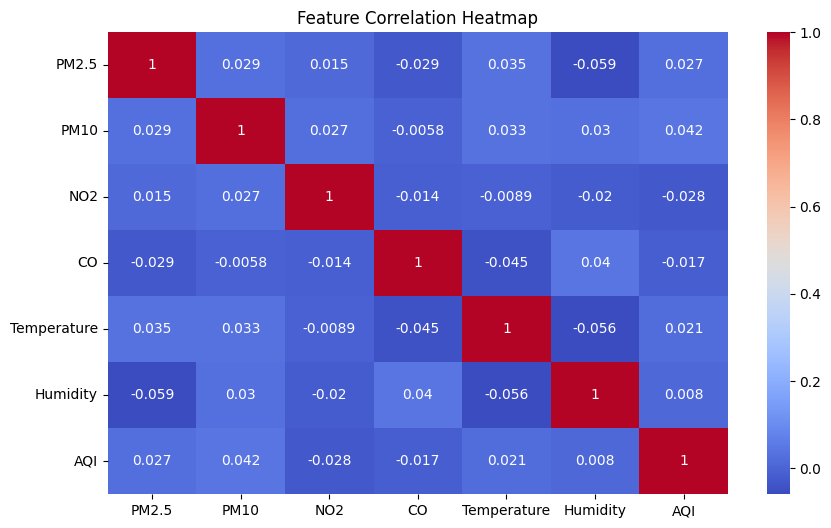

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['PM2.5','PM10','NO2','CO','Temperature','Humidity','AQI']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig("outputs/correlation_heatmap.png")


Text(0.5, 1.0, 'Feature Importance')

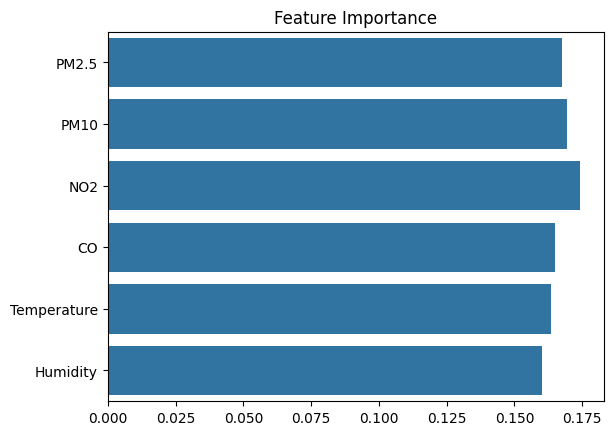

In [23]:
importances = rf_classifier.feature_importances_
features = ['PM2.5', 'PM10', 'NO2', 'CO', 'Temperature', 'Humidity']
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")

Text(0.5, 1.0, 'Random Forest Confusion Matrix')

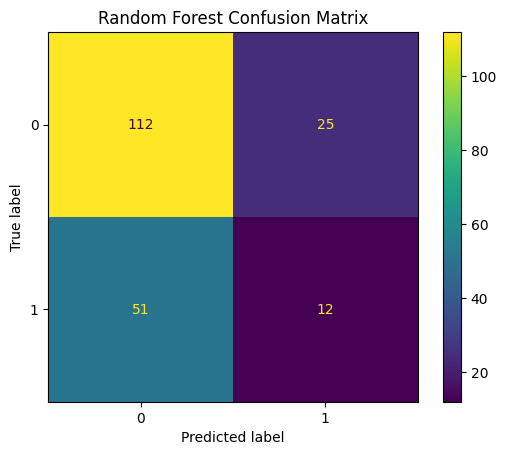

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_classifier, X_test, y_clf_test)
plt.title("Random Forest Confusion Matrix")

Text(0.5, 1.0, 'Actual vs Predicted AQI')

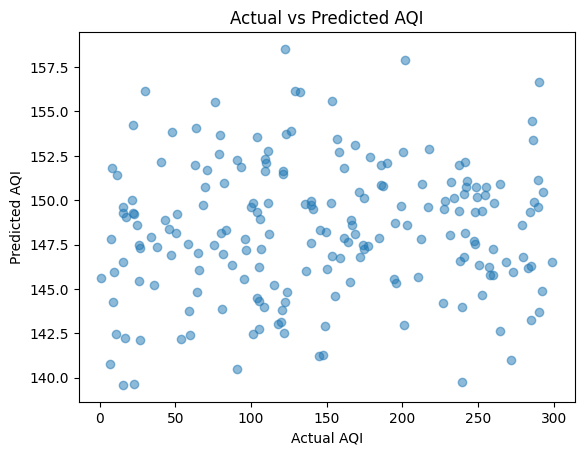

In [25]:
plt.scatter(y_reg_test, linear_model.predict(X_test_reg), alpha=0.5)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

<Axes: >

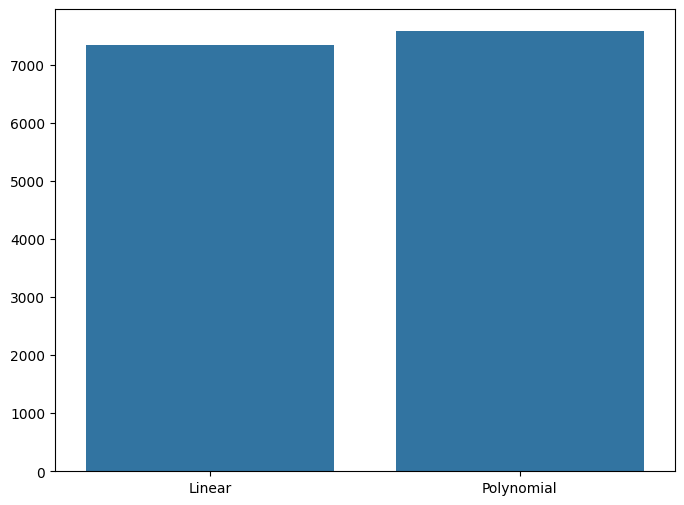

In [17]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
mses = [7329.39, 7573.59]

sns.barplot(x=list(reg_models.keys()), y=mses)